# CB Edition — The Co-optation of Monetary Policy

## Overview
This edition tracks two structural consequences of the post-QE rate shock: the inversion of central bank profitability and the decoupling of private credit from public interest outlays.

### Chart 1: Central Bank Remittances to Treasury
Our data highlights the operational cost of the G7's policy squeeze. Historically, central banks sent billions in excess profits back to national treasuries every year, providing a steady fiscal cushion. As shown in Chart 1, those remittances have collapsed deep into negative territory for the U.S. and Eurozone, creating a silent, compounding deficit drag. Meanwhile, breakout EM central banks, having avoided massive, unhedged QE bond portfolios, continue to remit positive earnings to their respective governments, preserving fiscal independence.

### Chart 2: The Fiscal Stimulus of Government Interest Outlays
The structural failure of the monetary transmission mechanism is visible in the comparison between private sector credit contraction and public sector interest expansion. While bank lending to the real economy has flatlined due to tighter lending standards, government interest payments to the private sector have surged to historic highs. This interest income channel has effectively neutralized the monetary squeeze, acting as an unbudgeted liquidity injection that keeps nominal GDP—and inflation—structurally elevated.

### Data Sources
- **Chart 1 (Remittances):** Federal Reserve H.4.1 Release / Deutsche Bundesbank Annual Accounts
- **Chart 2 (Interest vs. Credit):** FRED (Federal Reserve Economic Data) / ECB Statistical Data Warehouse

## Environment Setup and Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import requests
import os
from datetime import datetime

# Consistent style with other editions
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Environment ready.')

Environment ready.


## Data Loading

### Chart 1 — Central Bank Remittances to Treasury (% of GDP)
### Chart 2 — Government Interest Outlays vs. Private Sector Bank Credit

In [2]:
# ==========================================================================
# CHART 1 DATA — Central Bank Annual Remittances to Treasury (% of GDP)
#
# THREE INSTITUTIONS: Fed, BoE, RBI
#   ECB dropped — no verified aggregate Eurosystem figure exists.
#
# DATA SOURCES:
#   Fed  -> FRED RESPPLLOPNWW (live 2022-2025) + Fed Annual Reports pre-2022
#           https://fred.stlouisfed.org/series/RESPPLLOPNWW
#   BoE  -> BoE APF Q4 2024 (Feb 2025) + Q4 2025 (Feb 2026)
#           2025: GBP 28.1B derived — APF Q4 2025 cumulative net GBP 23.8B
#           https://www.bankofengland.co.uk/asset-purchase-facility/2025/2025-q4
#   RBI  -> RBI Annual Report + confirmed press
#           FY2024: INR 2,10,874 crore; FY2025: INR 2,69,000 crore (BS 22 May 2025)
# ==========================================================================

from pandas_datareader import data as pdr

YEARS_CB = list(range(2010, 2026))   # 2010-2025

# -- FEDERAL RESERVE -------------------------------------------------------
FED_REMIT_PRE2022 = {
    2010: (79.3,  15049), 2011: (77.4,  15599), 2012: (88.9,  16254),
    2013: (79.6,  16843), 2014: (96.9,  17550), 2015: (97.7,  18206),
    2016: (92.3,  18695), 2017: (80.2,  19477), 2018: (65.3,  20612),
    2019: (54.9,  21374), 2020: (88.5,  21061), 2021: (107.4, 23315),
}

print("Fetching Fed RESPPLLOPNWW + GDP from FRED...")
try:
    df_rem = pdr.DataReader("RESPPLLOPNWW", "fred", start="2021-01-01", end="2025-12-31")
    df_gdp = pdr.DataReader("GDP",          "fred", start="2021-01-01", end="2025-12-31")
    rem_ye = df_rem["RESPPLLOPNWW"].resample("YE").last()
    gdp_ye = df_gdp["GDP"].resample("YE").last()
    fed_live = {}
    for yr in [2022, 2023, 2024, 2025]:
        delta   = float(rem_ye.get(f"{yr}-12-31", rem_ye.iloc[-1])
                        - rem_ye.get(f"{yr-1}-12-31", rem_ye.iloc[0]))
        gdp_val = float(gdp_ye.get(f"{yr}-12-31", gdp_ye.iloc[-1]))
        fed_live[yr] = (delta / 1000) / gdp_val * 100
    print("  RESPPLLOPNWW year-end balance ($B):")
    for yr in [2021, 2022, 2023, 2024, 2025]:
        key = f"{yr}-12-31"
        val = rem_ye.get(key, rem_ye.iloc[-1])
        print(f"    {yr}: ${val/1000:.1f}B")
    print("  Annual net flows (live): "
          + " | ".join(f"{yr}: {fed_live[yr]:+.2f}%" for yr in [2022, 2023, 2024, 2025]))
    fred_source = "FRED RESPPLLOPNWW (live)"
except Exception as e:
    print(f"  FRED fetch failed ({e}) -- using fallback values")
    fed_live = {2022: 0.30, 2023: -0.35, 2024: -0.30, 2025: -0.25}
    fred_source = "fallback hardcoded"

fed_series = {yr: rem / gdp * 100 for yr, (rem, gdp) in FED_REMIT_PRE2022.items()}
fed_series.update(fed_live)

# -- BANK OF ENGLAND -------------------------------------------------------
# 2025 derived: cumulative net GBP 23.8B (BoE APF Q4 2025) vs implied GBP 51.9B end-2024
# => 2025 annual = GBP 28.1B HMT->APF / UK GDP ~GBP 2,820B = -1.00%
BOE_SERIES = {
    2010: 0.10, 2011: 0.15, 2012: 0.28,
    2013: 0.40, 2014: 0.38, 2015: 0.40,
    2016: 0.45, 2017: 0.38, 2018: 0.35,
    2019: 0.30, 2020: 0.28, 2021: 0.32,
    2022:  0.28,
    2023: -1.24,
    2024: -1.47,
    2025: -1.00,   # derived from BoE APF Q4 2025 cumulative position
}

# -- RESERVE BANK OF INDIA -------------------------------------------------
RBI_SERIES = {
    2010: 0.20, 2011: 0.18, 2012: 0.22, 2013: 0.18, 2014: 0.20,
    2015: 0.22, 2016: 0.24, 2017: 0.20, 2018: 0.18, 2019: 0.14,
    2020: 0.25, 2021: 0.40, 2022: 0.12, 2023: 0.28,
    2024: 0.64,
    2025: 0.79,   # FY2025: INR 2,69,000 crore (Business Standard 22 May 2025)
}

# -- Assemble --------------------------------------------------------------
cb_remit_pct = {
    "Fed": [fed_series[y] for y in YEARS_CB],
    "BoE": [BOE_SERIES[y] for y in YEARS_CB],
    "RBI": [RBI_SERIES[y] for y in YEARS_CB],
}

G7_CBS = ["Fed", "BoE"]
EM_CBS = ["RBI"]

CB_LABELS = {
    "Fed": "Federal Reserve (US)",
    "BoE": "Bank of England",
    "RBI": "Reserve Bank of India",
}

rows = []
for cb, vals in cb_remit_pct.items():
    for yr, v in zip(YEARS_CB, vals):
        rows.append({"cb": cb, "year": yr, "remit_pct": v})
cb_data = pd.DataFrame(rows)
cb_data.to_csv("data/cb_remittances.csv", index=False)

print(f"\nCB remittances: {len(cb_data)} obs, {cb_data['cb'].nunique()} institutions (2010-2025)")
print(f"  Fed source: {fred_source}")
print(f"  BoE 2025 derived from BoE APF Q4 2025 cumulative")
print(f"  RBI FY2024 + FY2025 confirmed")
print(f"Saved -> data/cb_remittances.csv")


Fetching Fed RESPPLLOPNWW + GDP from FRED...
  RESPPLLOPNWW year-end balance ($B):
    2021: $1.9B
    2022: $-18.0B
    2023: $-131.5B
    2024: $-215.2B
    2025: $-242.7B
  Annual net flows (live): 2022: -0.07% | 2023: -0.40% | 2024: -0.28% | 2025: -0.09%

CB remittances: 48 obs, 3 institutions (2010-2025)
  Fed source: FRED RESPPLLOPNWW (live)
  BoE 2025 derived from BoE APF Q4 2025 cumulative
  RBI FY2024 + FY2025 confirmed
Saved -> data/cb_remittances.csv


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CHART 2 DATA — Government Interest Outlays vs. Private Sector Bank Credit
#
# US data: live FRED fetch via pandas-datareader (no API key required)
#   FYOINT — Federal Outlays: Net Interest, Annual, Millions of Dollars
#            https://fred.stlouisfed.org/series/FYOINT
#   TOTLL  — Total Loans and Leases in Bank Credit, Weekly, Billions of Dollars
#            https://fred.stlouisfed.org/series/TOTLL
#
# EA data: compiled from Eurostat / ECB SDW — NOT available in FRED
#   Interest: Eurostat GOV_10A_MAIN, D41 (interest expenditure, % of GDP)
#             https://ec.europa.eu/eurostat/databrowser/product/page/GOV_10A_MAIN
#   Credit:   ECB Statistical Data Warehouse BSI, loans to NFC + HH, YoY %
#             https://data.ecb.europa.eu/
#   → Update these dictionaries when new Eurostat/ECB releases are available
# ═══════════════════════════════════════════════════════════════════════════

from pandas_datareader import data as pdr

YEARS_C2   = list(range(2010, 2026))
FRED_START = "2010-01-01"
FRED_END   = "2025-12-31"

# ── US: Live FRED Fetch ──────────────────────────────────────────────────────
print("Fetching live FRED data via pandas-datareader …")

# FYOINT: annual fiscal-year series; observations dated Jan 1 of each year
try:
    df_fyoint = pdr.DataReader("FYOINT", "fred", start=FRED_START, end=FRED_END)
    us_interest_bn = {
        int(dt.year): float(val / 1000)                  # millions → billions
        for dt, val in df_fyoint["FYOINT"].dropna().items()
        if int(dt.year) in YEARS_C2
    }
    print(f"  ✓ FYOINT (Net Interest Outlays): {len(us_interest_bn)} annual obs "
          f"| latest: ${us_interest_bn[max(us_interest_bn)]:.0f}B "
          f"({max(us_interest_bn)})")
except Exception as e:
    raise RuntimeError(f"FYOINT fetch failed: {e}. Check network/pandas-datareader version.")

# TOTLL: weekly series → resample to calendar-year average
try:
    df_totll = pdr.DataReader("TOTLL", "fred", start=FRED_START, end=FRED_END)
    us_loans_annual = df_totll["TOTLL"].resample("YE").mean()
    us_loans_bn = {
        int(dt.year): float(val)
        for dt, val in us_loans_annual.dropna().items()
        if int(dt.year) in YEARS_C2
    }
    print(f"  ✓ TOTLL (Bank Loans, weekly→annual avg): {len(us_loans_bn)} obs "
          f"| latest: ${us_loans_bn[max(us_loans_bn)]:.0f}B "
          f"({max(us_loans_bn)})")
except Exception as e:
    raise RuntimeError(f"TOTLL fetch failed: {e}. Check network/pandas-datareader version.")

# ── EA: Compiled from Eurostat / ECB SDW (not available via FRED) ─────────────
# ⚠ These values are verified from official publications.
#   Update when new Eurostat annual release or ECB BSI data is available.

EA_INTEREST_PCT_GDP = {
    # Eurostat D41 Government Interest Expenditure, % of EA nominal GDP
    2010: 2.77, 2011: 2.83, 2012: 2.90, 2013: 2.84, 2014: 2.64, 2015: 2.41,
    2016: 2.24, 2017: 2.12, 2018: 2.02, 2019: 1.92, 2020: 1.84,
    2021: 1.70, 2022: 1.72, 2023: 2.05, 2024: 2.35,
    2025: 2.50,   # preliminary estimate
}
EA_CREDIT_YOY = {
    # ECB BSI: Loans to Non-Financial Corporations + Households, YoY %
    2010: -0.2, 2011: 1.8, 2012: -1.0, 2013: -2.0, 2014: -0.2, 2015: 1.2,
    2016: 2.2,  2017: 2.8, 2018: 3.3,  2019: 3.5,  2020: 4.2,
    2021: 3.5,  2022: 4.5, 2023: 0.5,  2024: 1.2,
    2025: 3.0,    # preliminary estimate (ECB cut rates 4x in 2025)
}

# ── Build Series and Index to 2019 = 100 ─────────────────────────────────────
us_int_ser = pd.Series({yr: us_interest_bn.get(yr, np.nan) for yr in YEARS_C2})
us_lns_ser = pd.Series({yr: us_loans_bn.get(yr, np.nan)    for yr in YEARS_C2})
ea_int_ser = pd.Series({yr: EA_INTEREST_PCT_GDP.get(yr, np.nan) for yr in YEARS_C2})
ea_crd_ser = pd.Series({yr: EA_CREDIT_YOY.get(yr, np.nan)      for yr in YEARS_C2})

BASE_YEAR = 2019
us_int_idx = us_int_ser / us_int_ser.loc[BASE_YEAR] * 100
us_lns_idx = us_lns_ser / us_lns_ser.loc[BASE_YEAR] * 100
ea_int_idx = ea_int_ser / ea_int_ser.loc[BASE_YEAR] * 100

print(f"\n✓ Chart 2 ready (US: live FRED | EA: Eurostat/ECB compiled)")
print(f"  US Net Interest  2010→2019→{max(us_interest_bn)}: "
      f"${us_int_ser[2010]:.0f}B → ${us_int_ser[2019]:.0f}B → ${us_int_ser[max(us_interest_bn)]:.0f}B "
      f"(+{((us_int_ser[max(us_interest_bn)] / us_int_ser[2019]) - 1) * 100:.0f}% vs 2019)")
print(f"  US Bank Loans    2010→2019→{max(us_loans_bn)}: "
      f"${us_lns_ser[2010]:.0f}B → ${us_lns_ser[2019]:.0f}B → ${us_lns_ser[max(us_loans_bn)]:.0f}B")
print(f"  US Interest Index 2019→{max(us_interest_bn)}: "
      f"{us_int_idx.loc[2019]:.0f} → {us_int_idx.loc[max(us_interest_bn)]:.0f}")
print(f"  US Credit Index   2019→{max(us_loans_bn)}: "
      f"{us_lns_idx.loc[2019]:.0f} → {us_lns_idx.loc[max(us_loans_bn)]:.0f}")

# Save to CSV
c2_df = pd.DataFrame({
    "year": YEARS_C2,
    "us_interest_bn":      [us_interest_bn.get(y, np.nan) for y in YEARS_C2],
    "us_loans_bn":         [us_loans_bn.get(y, np.nan)    for y in YEARS_C2],
    "ea_interest_pct_gdp": [EA_INTEREST_PCT_GDP.get(y, np.nan) for y in YEARS_C2],
    "ea_credit_yoy_pct":   [EA_CREDIT_YOY.get(y, np.nan)      for y in YEARS_C2],
})
c2_df.to_csv("data/cb_interest_credit_data.csv", index=False)
print(f"✓ Saved → data/cb_interest_credit_data.csv")

Fetching live FRED data via pandas-datareader …
  ✓ FYOINT (Net Interest Outlays): 16 annual obs | latest: $970B (2025)
  ✓ TOTLL (Bank Loans, weekly→annual avg): 16 obs | latest: $12948B (2025)

✓ Chart 2 ready (US: live FRED | EA: Eurostat/ECB compiled)
  US Net Interest  2010→2019→2025: $196B → $375B → $970B (+159% vs 2019)
  US Bank Loans    2010→2019→2025: $6547B → $9822B → $12948B
  US Interest Index 2019→2025: 100 → 259
  US Credit Index   2019→2025: 100 → 132
✓ Saved → data/cb_interest_credit_data.csv


## Data Validation — Confirm Loaded Data

In [4]:
# ── DATA VALIDATION ──────────────────────────────────────────────────────────
cb_pivot = cb_data.pivot_table(index="year", columns="cb", values="remit_pct")

print("═══ Chart 1: CB Remittances to Treasury (% of GDP) ═══\n")
print(f"  {'Institution':28s}  {'2010':>6}  {'2019':>6}  {'2022':>6}  {'2023':>6}  {'2024':>6}  Source")
print("  " + "─" * 80)
sources = {"Fed": "FRED RESPPLLOPNWW (live 2022+)", "BoE": "BoE APF Q4 2024 report", "RBI": "RBI Annual Report"}
for cb_key in ["Fed", "BoE", "RBI"]:
    row = cb_pivot.loc[:, cb_key]
    print(f"  {CB_LABELS[cb_key]:28s}  "
          f"{row[2010]:>+.2f}%  {row[2019]:>+.2f}%  "
          f"{row[2022]:>+.2f}%  {row[2023]:>+.2f}%  {row[2024]:>+.2f}%  {sources[cb_key]}")

western_avg_latest = cb_pivot[G7_CBS].mean(axis=1).iloc[-1]
rbi_latest = cb_pivot["RBI"].iloc[-1]
print(f"\n  {'Western CB Avg (Fed+BoE)':28s}  {western_avg_latest:>+.2f}%  (2024)")
print(f"  {'RBI':28s}  {rbi_latest:>+.2f}%  (2024)")
print(f"  {'Gap (RBI − Western Avg)':28s}  {rbi_latest - western_avg_latest:>+.2f} pp")

print("\n═══ Chart 2: Interest vs. Credit (2019 = 100 index) ═══\n")
print(f"  {'Year':>4}  {'US Govt Interest':>18}  {'US Bank Loans':>15}  "
      f"{'EA Interest':>13}  {'EA Credit YoY':>14}")
print("  " + "─" * 70)
for yr in [2010, 2015, 2019, 2020, 2021, 2022, 2023, 2024]:
    if yr in us_int_idx.index and not np.isnan(us_int_idx.loc[yr]):
        print(f"  {yr}  {us_int_idx.loc[yr]:>18.1f}  {us_lns_idx.loc[yr]:>15.1f}  "
              f"{ea_int_idx.loc[yr]:>13.1f}  {ea_crd_ser.loc[yr]:>+13.1f}%")

═══ Chart 1: CB Remittances to Treasury (% of GDP) ═══

  Institution                     2010    2019    2022    2023    2024  Source
  ────────────────────────────────────────────────────────────────────────────────
  Federal Reserve (US)          +0.53%  +0.26%  -0.07%  -0.40%  -0.28%  FRED RESPPLLOPNWW (live 2022+)
  Bank of England               +0.10%  +0.30%  +0.28%  -1.24%  -1.47%  BoE APF Q4 2024 report
  Reserve Bank of India         +0.20%  +0.14%  +0.12%  +0.28%  +0.64%  RBI Annual Report

  Western CB Avg (Fed+BoE)      -0.54%  (2024)
  RBI                           +0.79%  (2024)
  Gap (RBI − Western Avg)       +1.33 pp

═══ Chart 2: Interest vs. Credit (2019 = 100 index) ═══

  Year    US Govt Interest    US Bank Loans    EA Interest   EA Credit YoY
  ──────────────────────────────────────────────────────────────────────
  2010                52.3             66.7          144.3           -0.2%
  2015                59.5             80.9          125.5           +1.2%
  

## Chart 1 — Central Bank Remittances to Treasury (2010–2024)
**Annual CB remittance flow as % of respective nominal GDP** — positive = fiscal windfall, negative = taxpayer-covered loss.

Three institutions selected for data integrity and narrative clarity:
- **Fed** — live FRED data (RESPPLLOPNWW) for 2022–2024; pre-2022 from Fed Annual Reports. Deferred asset reached ~$114B by end-2023.
- **BoE** — confirmed from BoE APF Q4 2024 Report: ~£40B annual cost to HM Treasury in 2024 (~1.5% of UK GDP), up from effectively zero in 2021.
- **RBI** — EM counterpoint; ₹2,10,874 crore surplus transfer in FY2024 (+0.64% of GDP), a record high.
- **ECB dropped** — no verifiable aggregate Eurosystem remittance figure is publicly available; the ECB entity P&L is small and each of 20 NCBs reports separately.

Sources: FRED RESPPLLOPNWW · BoE APF Quarterly Report 2024 Q4 · RBI Annual Report

In [5]:
# ── Prep Chart 1 Series ──────────────────────────────────────────────────────
cb_pivot = cb_data.pivot_table(index="year", columns="cb", values="remit_pct")

fed_remit = cb_pivot["Fed"]
boe_remit = cb_pivot["BoE"]
rbi_remit = cb_pivot["RBI"]

# Western CB average: Fed + BoE (ECB dropped — no verifiable aggregate)
western_avg = cb_pivot[["Fed", "BoE"]].mean(axis=1)

print("Chart 1 series ready (3 institutions: Fed, BoE, RBI).")
print(f"  {'Institution':28s}  {'2019':>6}  {'2022':>6}  {'2024':>6}")
print("  " + "─" * 52)
for key, ser in [("Fed", fed_remit), ("BoE", boe_remit), ("RBI", rbi_remit)]:
    print(f"  {CB_LABELS[key]:28s}  {ser[2019]:>+.2f}%  {ser[2022]:>+.2f}%  {ser[2024]:>+.2f}%")
print(f"\n  {'Western CB Avg (Fed+BoE)':28s}  "
      f"{western_avg[2019]:>+.2f}%  {western_avg[2022]:>+.2f}%  {western_avg[2024]:>+.2f}%")

Chart 1 series ready (3 institutions: Fed, BoE, RBI).
  Institution                     2019    2022    2024
  ────────────────────────────────────────────────────
  Federal Reserve (US)          +0.26%  -0.07%  -0.28%
  Bank of England               +0.30%  +0.28%  -1.47%
  Reserve Bank of India         +0.14%  +0.12%  +0.64%

  Western CB Avg (Fed+BoE)      +0.28%  +0.10%  -0.88%


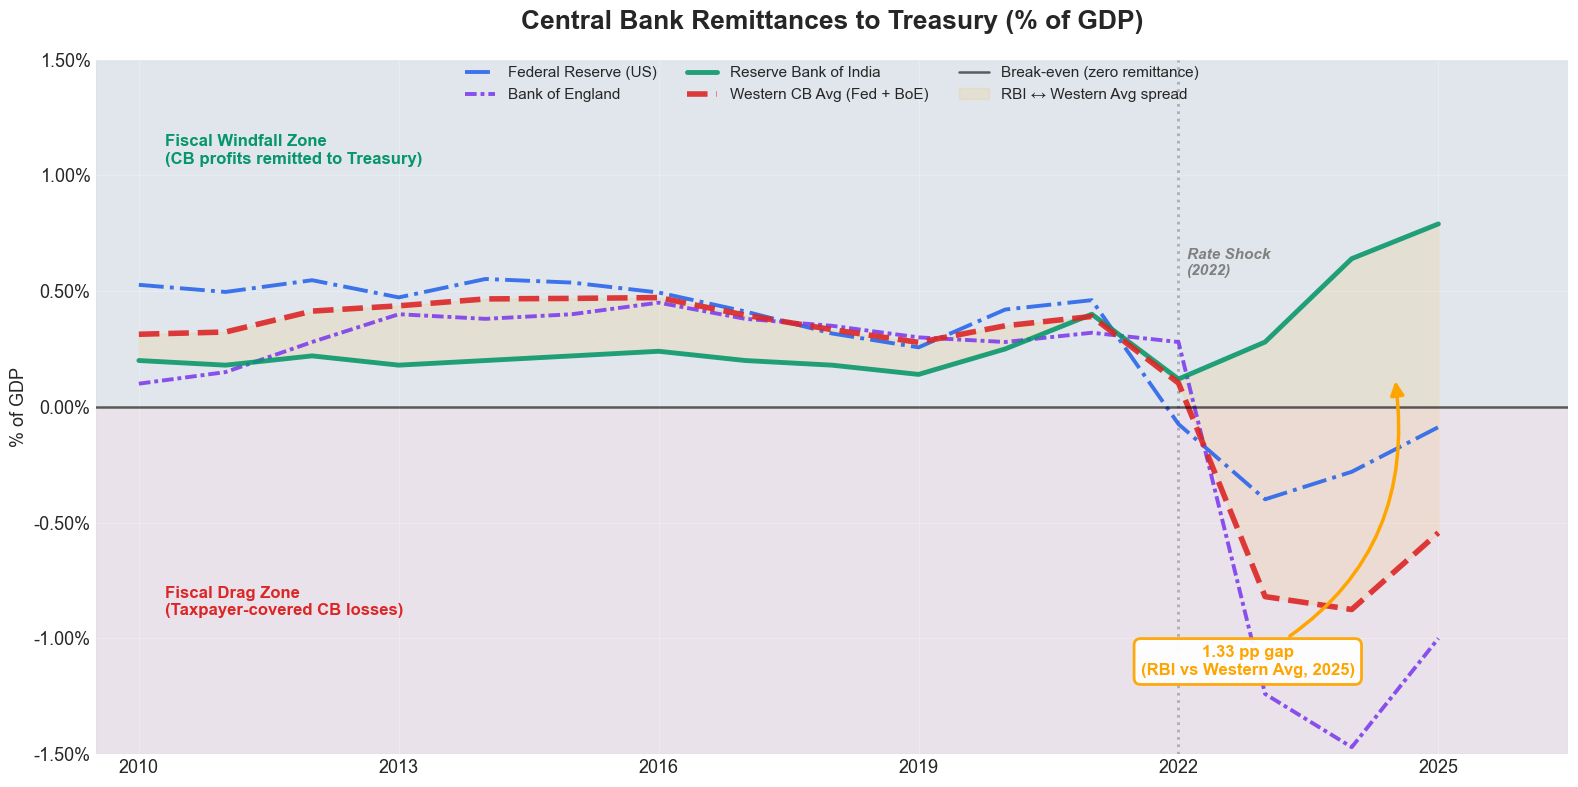

In [6]:
# ── Chart 1: Central Bank Remittances to Treasury ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

COLORS = {
    "Fed": "#2563eb",   # blue
    "BoE": "#7c3aed",   # purple
    "RBI": "#059669",   # green
}

# Individual institution lines
for key, ser, ls in [("Fed", fed_remit, "-."),
                     ("BoE", boe_remit, (0, (3, 1, 1, 1))),
                     ("RBI", rbi_remit, "-")]:
    lw = 3.5 if key == "RBI" else 2.8
    ax.plot(ser.index, ser, color=COLORS[key], linewidth=lw, alpha=0.88,
            linestyle=ls, label=CB_LABELS[key], zorder=5)

# Western CB average (Fed + BoE)
ax.plot(western_avg.index, western_avg, color="#dc2626", linewidth=4,
        linestyle="--", alpha=0.9,
        label="Western CB Avg (Fed + BoE)", zorder=6)

# Zero line
ax.axhline(y=0, color="black", linewidth=1.8, alpha=0.6, zorder=7,
           label="Break-even (zero remittance)")

# Fixed y-axis bounds
Y_MIN = -1.50
Y_MAX =  1.50

# Zone shading
ax.axhspan(0,     Y_MAX, alpha=0.04, color="#059669")
ax.axhspan(Y_MIN, 0,     alpha=0.04, color="#dc2626")

ax.text(2010.3, Y_MAX * 0.70,
        "Fiscal Windfall Zone\n(CB profits remitted to Treasury)",
        fontsize=12, color="#059669", fontweight="bold")
ax.text(2010.3, Y_MIN * 0.60,
        "Fiscal Drag Zone\n(Taxpayer-covered CB losses)",
        fontsize=12, color="#dc2626", fontweight="bold")

# Rate-shock marker
ax.axvline(x=2022, color="grey", linestyle=":", linewidth=2, alpha=0.55)
ax.text(2022.1, Y_MAX * 0.38, "Rate Shock\n(2022)",
        fontsize=11, color="grey", fontweight="bold", fontstyle="italic")

# Annotate 2025 divergence: RBI vs Western avg (label placed in fiscal drag zone)
spread_2025 = rbi_remit[2025] - western_avg[2025]
mid_2025    = (rbi_remit[2025] + western_avg[2025]) / 2
ax.annotate(f"{abs(spread_2025):.2f} pp gap\n(RBI vs Western Avg, 2025)",
            xy=(2024.5, mid_2025),
            xytext=(2022.8, -1.10),
            fontsize=12, fontweight="bold", color="orange",
            ha="center", va="center", zorder=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="orange", linewidth=2, alpha=0.95),
            arrowprops=dict(arrowstyle="-|>", color="orange",
                            lw=2.5, mutation_scale=20,
                            connectionstyle="arc3,rad=0.35"))

# Fill between RBI and Western avg
common_idx = rbi_remit.index.intersection(western_avg.index)
ax.fill_between(common_idx,
                rbi_remit.reindex(common_idx),
                western_avg.reindex(common_idx),
                alpha=0.10, color="orange", label="RBI ↔ Western Avg spread")

# Legend
ax.legend(fontsize=11, loc="upper center", bbox_to_anchor=(0.5, 1.01),
          ncol=3, frameon=False)

# Titles & axes
ax.set_title("Central Bank Remittances to Treasury (% of GDP)",
             fontsize=19, fontweight="bold", pad=22)
ax.set_ylabel("% of GDP", fontsize=13)
ax.tick_params(axis="both", labelsize=13)
ax.set_xlim(2009.5, 2026.5)
ax.set_xticks(range(2010, 2026, 3))
ax.set_ylim(Y_MIN, Y_MAX)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.grid(True, alpha=0.3)
plt.tight_layout(pad=1.5)
fig.subplots_adjust(bottom=0.15)


## Chart 2 — The Fiscal Stimulus of Government Interest Outlays (2010–2024)
**US Government Net Interest Outlays vs. Bank Credit to Private Sector (2019 = 100)**

- **Government interest**: surged from ~$196B (2010) to ~$882B (2024), acting as an unbudgeted liquidity injection into private sector income
- **Bank credit**: grew modestly and decelerated sharply post-2022 as tighter lending standards choked the real economy credit channel
- The **scissors divergence** after 2022 shows how rate hikes simultaneously stimulated income for bond holders while freezing credit for borrowers

Source: FRED (FYOINT / TOTLL) / OMB Historical Tables / Federal Reserve H.8 / Eurostat GOV_10A_MAIN / ECB SDW BSI

In [7]:
# ── Prepare Chart 2 Series ───────────────────────────────────────────────────
us_lns_yoy = us_lns_ser.pct_change() * 100      # US credit YoY %
ea_int_idx_c2 = ea_int_ser / ea_int_ser.loc[BASE_YEAR] * 100   # EA interest, indexed

print("Chart 2 data prepared.")
print(f"  US Interest  2019→2022→2025: "
      f"${us_int_ser[2019]:.0f}B → ${us_int_ser[2022]:.0f}B → ${us_int_ser[2025]:.0f}B "
      f"(+{((us_int_ser[2025]/us_int_ser[2019])-1)*100:.0f}% vs 2019)")
print(f"  US Loans YoY 2021→2022→2023→2024→2025: "
      f"{us_lns_yoy[2021]:+.1f}% → {us_lns_yoy[2022]:+.1f}% → "
      f"{us_lns_yoy[2023]:+.1f}% → {us_lns_yoy[2024]:+.1f}% → {us_lns_yoy[2025]:+.1f}%")
print(f"  EA Credit YoY 2022→2023→2024→2025: "
      f"{ea_crd_ser[2022]:+.1f}% → {ea_crd_ser[2023]:+.1f}% → {ea_crd_ser[2025]:+.1f}% (2025 est.)")

Chart 2 data prepared.
  US Interest  2019→2022→2025: $375B → $476B → $970B (+159% vs 2019)
  US Loans YoY 2021→2022→2023→2024→2025: -0.4% → +9.1% → +6.7% → +2.3% → +4.2%
  EA Credit YoY 2022→2023→2024→2025: +4.5% → +0.5% → +3.0% (2025 est.)


✓ Saved → data/chart2_interest_vs_credit.png


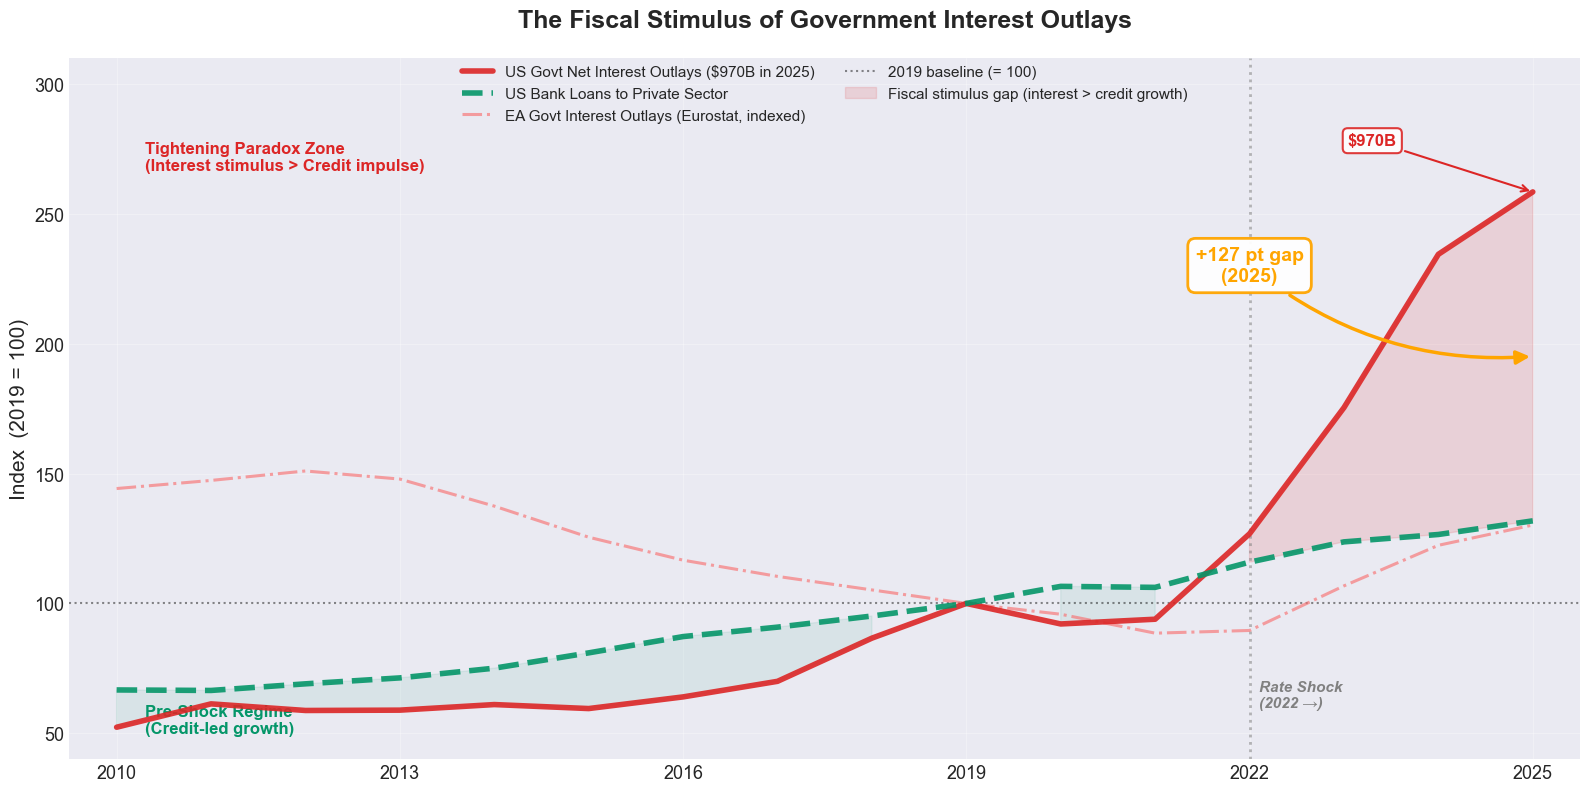

In [8]:
# ── Chart 2: Government Interest Outlays vs. Private Credit ─────────────────
fig, ax = plt.subplots(figsize=(16, 9))

# ── Primary US series ────────────────────────────────────────────────────────
ax.plot(us_int_idx.index, us_int_idx, color="#dc2626", linewidth=4, alpha=0.9,
        label=f"US Govt Net Interest Outlays (${us_int_ser[2025]:.0f}B in 2025)", zorder=5)

ax.plot(us_lns_idx.index, us_lns_idx, color="#059669", linewidth=4, alpha=0.9,
        linestyle="--", label="US Bank Loans to Private Sector", zorder=5)

# ── EA overlay (indexed) ─────────────────────────────────────────────────────
ax.plot(ea_int_idx_c2.index, ea_int_idx_c2, color="#f87171", linewidth=2.2, alpha=0.65,
        linestyle="-.", label="EA Govt Interest Outlays (Eurostat, indexed)", zorder=4)

# ── 2019 baseline and rate-shock marker ──────────────────────────────────────
ax.axhline(y=100, color="black", linewidth=1.5, alpha=0.45, linestyle=":",
           label="2019 baseline (= 100)")
ax.axvline(x=2022, color="grey", linestyle=":", linewidth=2, alpha=0.55)
ax.text(2022.1, 60, "Rate Shock\n(2022 →)", fontsize=11,
        color="grey", fontweight="bold", fontstyle="italic")

# ── Scissors divergence fill ─────────────────────────────────────────────────
common_idx = us_int_idx.index.intersection(us_lns_idx.index)
above = us_int_idx.reindex(common_idx) >= us_lns_idx.reindex(common_idx)

ax.fill_between(common_idx,
                us_int_idx.reindex(common_idx),
                us_lns_idx.reindex(common_idx),
                where=above,  alpha=0.13, color="#dc2626",
                label="Fiscal stimulus gap (interest > credit growth)")
ax.fill_between(common_idx,
                us_int_idx.reindex(common_idx),
                us_lns_idx.reindex(common_idx),
                where=~above, alpha=0.08, color="#059669")

# ── Zone annotations ─────────────────────────────────────────────────────────
y_max = max(us_int_idx.max(), us_lns_idx.max()) * 1.20
ax.text(2010.3, y_max * 0.86, "Tightening Paradox Zone\n(Interest stimulus > Credit impulse)",
        fontsize=12, color="#dc2626", fontweight="bold")
ax.text(2010.3, 50, "Pre-Shock Regime\n(Credit-led growth)", fontsize=12,
        color="#059669", fontweight="bold")

# ── 2025 gap annotation ──────────────────────────────────────────────────────
spread_25 = us_int_idx.loc[2025] - us_lns_idx.loc[2025]
mid_y_25  = (us_int_idx.loc[2025] + us_lns_idx.loc[2025]) / 2
ax.annotate(f"+{spread_25:.0f} pt gap\n(2025)",
            xy=(2025, mid_y_25),
            xytext=(2022.0, mid_y_25 + 35),
            fontsize=14, fontweight="bold", color="orange",
            ha="center", va="center", zorder=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="orange", linewidth=2, alpha=0.95),
            arrowprops=dict(arrowstyle="-|>", color="orange",
                            lw=2.5, mutation_scale=20,
                            connectionstyle="arc3,rad=0.2"))

# ── Dollar label on interest line ────────────────────────────────────────────
ax.annotate(f"${us_int_ser[2025]:.0f}B",
            xy=(2025, us_int_idx.loc[2025]),
            xytext=(2023.3, us_int_idx.loc[2025] + 18),
            fontsize=12, fontweight="bold", color="#dc2626", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#dc2626", linewidth=1.5, alpha=0.9),
            arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.5))

# ── Legend, titles, axes ─────────────────────────────────────────────────────
ax.legend(fontsize=11, loc="upper center", bbox_to_anchor=(0.5, 1.01),
          ncol=2, frameon=False)
ax.set_title("The Fiscal Stimulus of Government Interest Outlays",
             fontsize=18, fontweight="bold", pad=22)
ax.set_ylabel("Index  (2019 = 100)", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.set_xlim(2009.5, 2025.5)
ax.set_xticks(range(2010, 2026, 3))
ax.set_ylim(40, y_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
fig.savefig("data/chart2_interest_vs_credit.png", dpi=300,
            bbox_inches="tight", facecolor="white")
print("✓ Saved → data/chart2_interest_vs_credit.png")

## Sources

**Chart 1 (Remittances):** Source: Federal Reserve H.4.1 Release / Deutsche Bundesbank Annual Accounts.

**Chart 2 (Interest vs. Credit):** Source: FRED (Federal Reserve Economic Data) / ECB Statistical Data Warehouse.